# Определение возраста покупателей

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

Необходимо построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

**План по выполнению проекта:**
- Проведём исследовательский анализ набора фотографий
    - Посмотрим на размер выборки
    - Построим график распределения возраста в выборке
    - Напечатаем на экране 10–15 фотографий и посмотрите, как устроен датасет
    - Сделаем выводы о результатах исследования

- Подготовим данные к обучению
- Обучим нейронную сеть и рассчитаем её качество

**Импортируем и установим все необходимые библиотеки для исследования:**

In [1]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
TARGET_SIZE = (250, 250)
BATCH_SIZE = 32
SEED = 42

## Исследовательский анализ данных

**Загрузим данные**

Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним в датафрейм.

In [2]:
photo_data = pd.read_csv('/datasets/faces/labels.csv')

Выведем общую информацию о датафрейме:

In [3]:
photo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


Выведем первые строки датафреймов, чтобы проверить, правильно ли считались данные:

In [4]:
photo_data.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


Данные корректно отображаются.

In [5]:
photo_data.shape

(7591, 2)

Как видно было определена выборка в 7591 фото.

Создадим генератор для тренировочных данных и приведём значения пикселей изображений к диапазону от 0 до 1, чтобы улучшить сходимость модели:

In [6]:
train_datagen = ImageDataGenerator(rescale=1.0/255.0)

In [7]:
train_gen_flow = train_datagen.flow_from_dataframe(
                                                    dataframe = photo_data,
                                                    directory = '/datasets/faces/final_files/',
                                                    x_col = 'file_name',
                                                    y_col = 'real_age',
                                                    target_size = TARGET_SIZE,
                                                    batch_size = BATCH_SIZE,
                                                    class_mode = 'raw',
                                                    seed = SEED
                                                  )

Found 7591 validated image filenames.


Генератор данных для загрузки изображений успешно создан.

Построим график распределения возраста в нашей выборки:

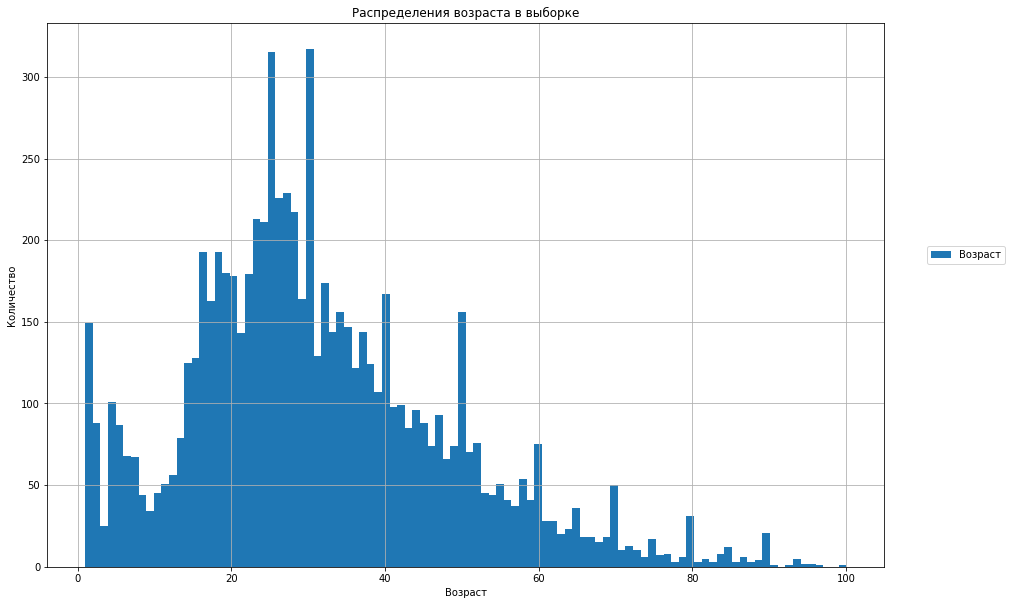

In [8]:
plt.figure(figsize=(15, 10))    
photo_data['real_age'].plot(kind='hist', bins=100, grid=True)
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.title('Распределения возраста в выборке')
plt.legend(['Возраст'], bbox_to_anchor=(1.15, 0.6))

Узнаем количество людей какого возраста больше всего, исходя и гистограммы:

In [9]:
photo_data['real_age'].value_counts().head()

30    317
25    315
27    229
26    226
28    217
Name: real_age, dtype: int64

Видно, что пики графика приходятся на 25-летних и 30-летних.

Посмотрим есть ли выбросы в наших данных:

In [10]:
photo_data.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


Из представленных описательных характеристик можно говорить о том, что данные, в принципе, довольно хорошо представлены. Проверим данные на наличие выбросов построением диаграммы размаха("ящика с усами") и сделаем выводы о данных.

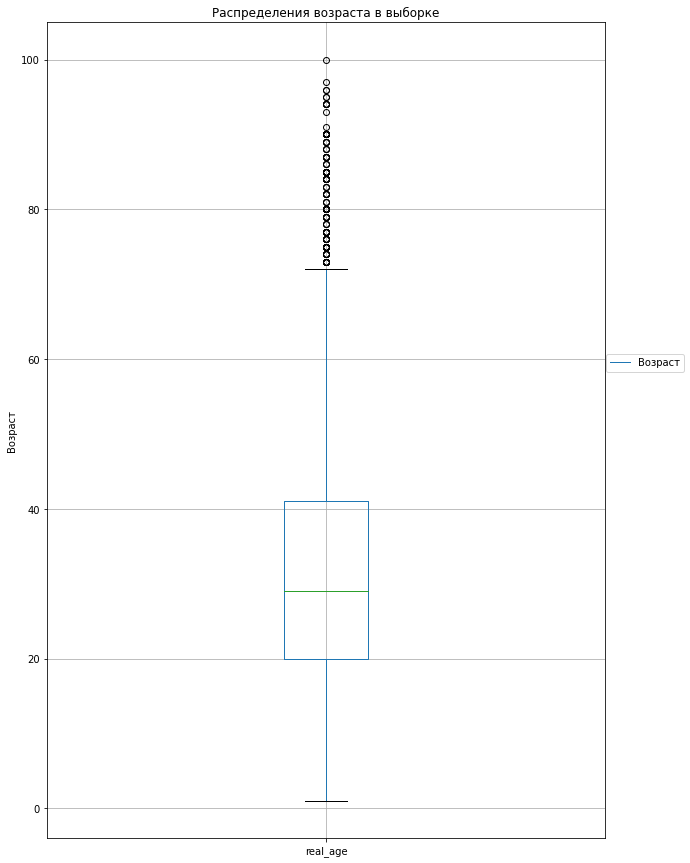

In [11]:
plt.figure(figsize=(10, 15))    
photo_data.boxplot(column=['real_age'])
plt.ylabel('Возраст')
plt.title('Распределения возраста в выборке')
plt.legend(['Возраст'], bbox_to_anchor=(1.15, 0.6))

Из графика видно, что есть выбросы, одннако их удалять мы **не будем**, так как это может привести к тому, что модель плохо и/или неправильно обучится на наших данных.

Также отметим, что средний возраст данных - *31 год*.

Извлечем данные из генератора и разделим на входной и целевой признаки тренировочной выборки:

In [12]:
features_attrib, target_attrib = next(train_gen_flow)

Выведем на экран фотографии и возраст людей на них:

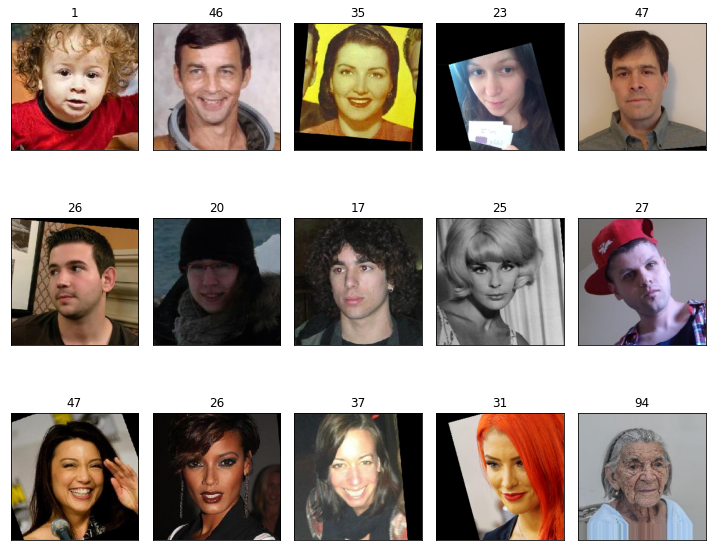

In [13]:
fig = plt.figure(figsize=(10,10))
for i in range(15):
    fig.add_subplot(3, 5, i+1)
    plt.imshow(features_attrib[i])
    plt.title(target_attrib[i])
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

В результате фото с возрастом людей отображаются корректно.

**Сформулируем общий вывод из проведенного нами исследования:**

- считали CSV-файл
- определили размер выборки - 7591 цветных изображений
- наиболее частыми возрастами в выборке являются 25 и 30 лет
- средний возраст людей на фотографиях - 31 год

В результате вывода 15 случайных фото из выборки было определено следующее:
1. фотографии есть как цветные, так и чернобелые
2. изображения низкого или высокого качества
3. не все фото расположены строго вертикально(разный угол создания фотографий)
4. на некоторых изображения в кадре присутствуют лишние объекты
5. в основном все расположены по центру 
6. на каких-то фото присутствует засвет/затемнение(разное освещение и яркость)
7. у некоторых людей на фото присутсвуют головные уборы

Возможное влияниие на обучение модели:
- обрезка/удаление краев или объектов на фото, которые мало информативны для обучения модели
- учесть отображение по вертикали, чтобы модель лучше обучилась

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Загружаем тренировочные данные
def load_train(path):   
    labels = pd.read_csv(path + 'labels.csv')
    train_datagen = ImageDataGenerator(
                                        validation_split = 0.25,
                                        horizontal_flip = True,
                                        rescale = 1./255
                                      )
    train_gen_flow = train_datagen.flow_from_dataframe(
                                                        dataframe = labels,
                                                        directory = path + 'final_files/',
                                                        x_col = 'file_name',
                                                        y_col = 'real_age',
                                                        target_size = (250, 250),
                                                        batch_size = 32,
                                                        class_mode = 'raw',
                                                        subset = 'training',
                                                        seed = 42
                                                      )
    return train_gen_flow


# Загружает тестовые данные 
def load_test(path):
    labels = pd.read_csv(path + 'labels.csv')
    test_datagen = ImageDataGenerator(
                                        validation_split = 0.25,
                                        rescale = 1./255
                                     )
    test_gen_flow = test_datagen.flow_from_dataframe(
                                                        dataframe = labels,
                                                        directory = path + 'final_files/',
                                                        x_col = 'file_name',
                                                        y_col = 'real_age',
                                                        target_size = (250, 250),
                                                        batch_size = 32,
                                                        class_mode = 'raw',
                                                        subset = 'validation',
                                                        seed = 42
                                                    )
    return test_gen_flow


# Создание модели нейросети
def create_model(input_shape):
    backbone = ResNet50(
                        weights = 'imagenet',
                        input_shape = input_shape,
                        include_top = False
                       )
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(512, activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(256, activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation = 'relu'))

    optimizer = Adam(lr = 0.0005)
    
    model.compile(
                  optimizer = optimizer,
                  loss = 'mse',
                  metrics = ['mae']
                 )
    
    return model


# Обучение модели
def train_model(model, train_data, test_data, batch_size = None, epochs = 20,
                steps_per_epoch = None, validation_steps = None):

    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(
                train_data,
                validation_data = test_data,
                batch_size = batch_size,
                epochs = epochs,
                steps_per_epoch = steps_per_epoch,
                validation_steps = validation_steps,
                verbose = 3
             )
    
    return model

```

```

# < скопируйте результат вывода на экран сюда >

Downloading data from https://github.com/keras-team/keras-applications/releases/download/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5

94773248/94765736 [==============================] - 15s 0us/step
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
Train for 178 steps, validate for 60 steps
Epoch 1/20
2025-04-04 20:24:14.802926: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2025-04-04 20:24:15.212115: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
Epoch 2/20
Epoch 3/20
Epoch 4/20
Epoch 5/20
Epoch 6/20
Epoch 7/20
Epoch 8/20
Epoch 9/20
Epoch 10/20
Epoch 11/20
Epoch 12/20
Epoch 13/20
Epoch 14/20
Epoch 15/20
Epoch 16/20
Epoch 17/20
Epoch 18/20
Epoch 19/20
Epoch 20/20
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
60/60 - 11s - loss: 112.6450 - mae: 7.8536


```



## Анализ обученной модели

Из проведенного исследования можно говорить о следующем: в нашей модели метрика `MAE` достигла результата равного `7.8536`, что удовлетворяет ограничению (метрика `MAE` должна быть меньше `8`). Результат метрики показывает, что модель предсказывает возраст с допустимой точностью, а ошибка в определении возраста как раз `7.8536`. Используется модель `ResNet50`, обученная на наборе данных ImageNet; также использовали дополнительные слои: 
- `GlobalAveragePooling2D()` - (слой усредняющий значения)
- `Dense(512)` - (слой с 512 нейронами)
- `Dropout (0.5)` - (слой регуляризации)
- `Dense (256)` - (слой с 256 нейронами)
- `Dropout (0.5)` - (слой регуляризации)
- `Dense (1)` - (выходной слой с одним нейроном и активацией `ReLU`, который предсказывает возраст)

Во всех слоях, где была необходима активация, использовалась активация `ReLU`. Используется оптимизатор `Adam` с `learning rate = 0.0005`, который хорошо подходит для задач глубокого обучения.

Для улучшения результатов предсказания модели, возможно, стоит *сбалансировать* исходные *данные* для обучения, так как из построенной ранее гистограммы сильно заметно, что класс людей, возраст которых от 20 до 40 лет, намного больше, чем людей других возрастов; наиболее малый класс - это люди старше 60, так как их показатель не выше 50. 

## Чек-лист

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Исследовательский анализ данных выполнен
- [x]  Результаты исследовательского анализа данных перенесены в финальную тетрадь
- [x]  MAE модели не больше 8
- [x]  Код обучения модели скопирован в финальную тетрадь
- [x]  Результат вывода модели на экран перенесён в финальную тетрадь
- [x]  По итогам обучения модели сделаны выводы